# NBA Injury Risk — Data Collection

In [1]:
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players
import pandas as pd
import time

# Find LeBron's player ID
lebron = players.find_players_by_full_name('LeBron James')[0]
print(lebron)

{'id': 2544, 'full_name': 'LeBron James', 'first_name': 'LeBron', 'last_name': 'James', 'is_active': True}


.stats.endpoints — this is the module that contains all the different data endpoints the NBA API offers. Each endpoint is a different type of data:

- playergamelog — game-by-game stats for one player
- leaguegamefinder — find games matching certain criteria
- teamdashboardbygeneralsplits — team stats broken down by situation

Think of endpoints as different "menus" at the restaurant. Each one gives you a different type of data.

.stats.static — contains static reference data that doesn't change often:

- players — full list of every NBA player ever with their IDs
- teams — all 30 NBA teams with their IDs

In [2]:
# Pull LeBron's game log for this season
gamelog = playergamelog.PlayerGameLog(
    player_id=2544,
    season='2024-25'
)

df = gamelog.get_data_frames()[0]
print(df.shape)
df.head()

(70, 27)


,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22024,2544,0022401185,"Apr 11, 2025",LAL vs. HOU,W,22,6,11,0.545,...,4,4,8,1,0,1,1,14,5,1
1,22024,2544,0022401159,"Apr 09, 2025",LAL @ DAL,W,36,11,20,0.550,...,5,7,3,1,0,2,2,27,18,1
2,22024,2544,0022401153,"Apr 08, 2025",LAL @ OKC,L,35,8,19,0.421,...,7,7,3,1,0,6,1,28,-23,1
3,22024,2544,0022401135,"Apr 06, 2025",LAL @ OKC,W,34,9,16,0.563,...,1,3,7,1,0,2,0,19,7,1
4,22024,2544,0022401126,"Apr 04, 2025",LAL vs. NOP,W,33,9,17,0.529,...,0,0,8,2,0,1,1,27,7,1


In [ ]:
#to see all columns so we can decide which ones are useful for our model (injury risk)
print(df.columns.tolist())

['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE']


MIN is the key column for workload. GAME_DATE for calculating rest days and back-to-backs.

But you only got 5 rows — that's because the current season hasn't been played yet. Let's pull last season instead:

In [4]:
gamelog = playergamelog.PlayerGameLog(
    player_id=2544,
    season='2023-24'
)

df = gamelog.get_data_frames()[0]
print(df.shape)
df[['GAME_DATE', 'MIN', 'PTS', 'REB', 'AST']].head(10)

(71, 27)


,GAME_DATE,MIN,PTS,REB,AST
0,"Apr 14, 2024",38,28,11,17
1,"Apr 12, 2024",41,37,9,5
2,"Apr 09, 2024",36,33,7,11
3,"Apr 06, 2024",36,24,5,12
4,"Apr 03, 2024",36,25,7,9
5,"Apr 02, 2024",29,23,4,9
6,"Mar 31, 2024",37,40,7,5
7,"Mar 29, 2024",35,16,10,8
8,"Mar 27, 2024",35,23,14,12
9,"Mar 24, 2024",38,26,5,10


71 games, perfect. You can see LeBron's minutes and stats for each game.

Now let's build the core workload features. This is the most important part of the whole project:


In [5]:
# Convert date and sort chronologically
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values('GAME_DATE').reset_index(drop=True)

# Convert MIN to numeric (sometimes comes as '38:00' string)
df['MIN'] = pd.to_numeric(df['MIN'], errors='coerce')

# Workload features
df['minutes_last_7_days'] = df['MIN'].rolling(window=7).sum()
df['minutes_last_28_days'] = df['MIN'].rolling(window=28).sum()
df['acute_chronic_ratio'] = (df['minutes_last_7_days'] / 7) / (df['minutes_last_28_days'] / 28)

# Rest days between games
df['days_rest'] = df['GAME_DATE'].diff().dt.days

# Back to back flag (less than 2 days rest)
df['is_back_to_back'] = (df['days_rest'] <= 1).astype(int)

df[['GAME_DATE', 'MIN', 'minutes_last_7_days', 'acute_chronic_ratio', 'days_rest', 'is_back_to_back']].head(10)

,GAME_DATE,MIN,minutes_last_7_days,acute_chronic_ratio,days_rest,is_back_to_back
0,2023-10-24,29,NaN,NaN,NaN,0
1,2023-10-26,35,NaN,NaN,2.0,0
2,2023-10-29,39,NaN,NaN,3.0,0
3,2023-10-30,33,NaN,NaN,1.0,1
4,2023-11-01,42,NaN,NaN,2.0,0
5,2023-11-04,35,NaN,NaN,3.0,0
6,2023-11-06,37,250.0,NaN,2.0,0
7,2023-11-08,27,248.0,NaN,2.0,0
8,2023-11-10,36,249.0,NaN,2.0,0
9,2023-11-14,23,233.0,NaN,4.0,0


The NaNs are expected for the first 28 rows — same reason as lag features, there's not enough history yet.

# What acute:chronic ratio means in plain English:

It compares your recent workload to your average workload:

- acute = average minutes per day over the last 7 days (short term)
- chronic = average minutes per day over the last 28 days (long term)

If the ratio is above 1.5 → you're playing significantly more than your recent average → injury danger zone. Your body isn't adapted to the sudden spike.

If the ratio is around 1.0 → your workload is consistent → low risk.

Real sports scientists at every professional team use this exact metric. It's called the ACWR — Acute:Chronic Workload Ratio.

In [6]:
#to see the non-null rows:
df[['GAME_DATE', 'MIN', 'acute_chronic_ratio', 'is_back_to_back']].dropna().head(10)

,GAME_DATE,MIN,acute_chronic_ratio,is_back_to_back
27,2023-12-25,37,1.037500,0
28,2023-12-28,25,1.050209,0
29,2023-12-30,39,1.041667,0
30,2023-12-31,37,1.048017,1
31,2024-01-03,38,1.038422,0
32,2024-01-05,39,1.050000,0
33,2024-01-07,38,1.050883,0
34,2024-01-09,35,1.044745,0
35,2024-01-11,24,1.043841,0
36,2024-01-15,39,1.040583,0


Lebron has NO games where the ratio goes above 1.5

-> LeBron's minutes are managed very consistently by the Lakers. He rarely spikes above his average workload. That's actually a useful insight — well-managed players have stable ratios around 1.0.

Now we need injury data to use as our target variable. We can't pull this from the NBA API — we need a separate dataset.

In [8]:
injuries = pd.read_csv('nba_injuries.csv')
print(injuries.shape)
print(injuries.columns.tolist())
injuries.head()

(37667, 6)
['Unnamed: 0', 'Date', 'Team', 'Acquired', 'Relinquished', 'Notes']


,Unnamed: 0,Date,Team,Acquired,Relinquished,Notes
0,0,1951-12-25,Bullets,NaN,Don Barksdale,placed on IL
1,1,1952-12-26,Knicks,NaN,Max Zaslofsky,placed on IL with torn side muscle
2,2,1956-12-29,Knicks,NaN,Jim Baechtold,placed on inactive list
3,3,1959-01-16,Lakers,NaN,Elgin Baylor,player refused to play after being denied a ro...
4,4,1961-11-26,Lakers,NaN,Elgin Baylor,player reported for military duty


- 37,667 injury records going back decades

The key columns are:

- Date — when the injury happened
- Relinquished — player who got injured (moved to injured reserve)
- Acquired — player who came back from injury
- Notes — what the injury was

In [9]:
# Look at recent injuries only
injuries['Date'] = pd.to_datetime(injuries['Date'])
injuries_recent = injuries[injuries['Date'] >= '2015-01-01']

# Filter to actual injuries (relinquished = player went on IR)
injured = injuries_recent[injuries_recent['Relinquished'].notna()]
print(injured.shape)
injured[['Date', 'Relinquished', 'Notes']].head(10)

(8542, 6)


,Date,Relinquished,Notes
21352,2015-01-01,Omri Casspi,placed on IL with left knee injury
21353,2015-01-02,Larry Sanders (b. 1988-11-21),placed on IL
21354,2015-01-02,Tim Hardaway Jr.,placed on IL with concussion
21356,2015-01-02,Maurice Harkless / Moe Harkless,placed on IL
21358,2015-01-02,Cory Jefferson,placed on IL
21360,2015-01-02,Spencer Dinwiddie,placed on IL
21362,2015-01-02,Tyler Ennis,placed on IL
21364,2015-01-03,Victor Claver,placed on IL
21366,2015-01-03,Mike Dunleavy Jr.,placed on IL with right ankle injury
21367,2015-01-03,Patrick Christopher,placed on IL with right knee injury


In [10]:
# to see actual injury types
print(injured['Notes'].value_counts().head(20))

Notes
placed on IL                                         2175
placed on IL with NBA health and safety protocols     522
placed on IL with illness                             443
placed on IL with sprained left ankle                 284
placed on IL with sprained right ankle                280
placed on IL with sore left knee                      180
placed on IL with sore right knee                     177
placed on IL for rest                                 154
placed on IL with concussion                          113
placed on IL with left knee injury                    105
placed on IL with sore lower back                      91
placed on IL with sore left ankle                      84
placed on IL with right knee injury                    79
placed on IL with sore right ankle                     71
placed on IL with left hamstring injury                59
placed on IL with back injury                          57
placed on IL with strained left hamstring              57
placed o

knee and ankle injuries are the most common in the NBA. These are exactly the soft tissue injuries that workload data can predict.

Now let's clean the injury data and create our target variable:

In [11]:
# Clean player names for merging later
injured['player_name'] = injured['Relinquished'].str.strip()
injured['injury_date'] = injured['Date']

# Flag soft tissue injuries (most predictable from workload)
soft_tissue_keywords = ['knee', 'ankle', 'hamstring', 'calf', 'achilles', 'quad', 'groin']

injured['is_soft_tissue'] = injured['Notes'].str.lower().str.contains(
    '|'.join(soft_tissue_keywords), na=False
).astype(int)

print(f"Total injuries: {len(injured)}")
print(f"Soft tissue injuries: {injured['is_soft_tissue'].sum()}")

injured[['player_name', 'injury_date', 'Notes', 'is_soft_tissue']].head(10)

Total injuries: 8542
Soft tissue injuries: 2823


,player_name,injury_date,Notes,is_soft_tissue
21352,Omri Casspi,2015-01-01,placed on IL with left knee injury,1
21353,Larry Sanders (b. 1988-11-21),2015-01-02,placed on IL,0
21354,Tim Hardaway Jr.,2015-01-02,placed on IL with concussion,0
21356,Maurice Harkless / Moe Harkless,2015-01-02,placed on IL,0
21358,Cory Jefferson,2015-01-02,placed on IL,0
21360,Spencer Dinwiddie,2015-01-02,placed on IL,0
21362,Tyler Ennis,2015-01-02,placed on IL,0
21364,Victor Claver,2015-01-03,placed on IL,0
21366,Mike Dunleavy Jr.,2015-01-03,placed on IL with right ankle injury,1
21367,Patrick Christopher,2015-01-03,placed on IL with right knee injury,1


2823 soft tissue injuries to work with. solid dataset for modeling.

NOW, We need to combine two things:

1) Player workload data (from NBA API) — one row per game
2) Injury data — did this player get injured in the next 14 days?

This is labeling — creating the target variable. For each game row, we ask: "did this player get injured within 14 days of this game?"


Let's first build a function that pulls game logs for multiple players:

In [12]:
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players
import time

def get_player_gamelog(player_name, season):
    """Pull game log for one player for one season"""
    try:
        # Find player ID
        player = players.find_players_by_full_name(player_name)
        if not player:
            return None
        
        player_id = player[0]['id']
        
        # Pull game log
        time.sleep(0.6)  # respect rate limit
        log = playergamelog.PlayerGameLog(
            player_id=player_id,
            season=season
        )
        
        df = log.get_data_frames()[0]
        df['player_name'] = player_name
        df['player_id'] = player_id
        return df
        
    except Exception as e:
        print(f"Failed for {player_name}: {e}")
        return None

# Test it
test = get_player_gamelog('Stephen Curry', '2023-24')
print(test.shape)

(74, 29)


Perfect. The function works.

Now let's pull game logs for a bigger list of players. We'll use 20 star players across multiple seasons — enough data to train a model:

In [13]:
star_players = [
    'LeBron James', 'Stephen Curry', 'Kevin Durant',
    'Giannis Antetokounmpo', 'Jayson Tatum', 'Luka Doncic',
    'Nikola Jokic', 'Joel Embiid', 'Damian Lillard',
    'Kawhi Leonard', 'Paul George', 'Anthony Davis',
    'Zion Williamson', 'Ja Morant', 'Devin Booker',
    'Jimmy Butler', 'Bam Adebayo', 'Trae Young',
    'Donovan Mitchell', 'Karl-Anthony Towns'
]

seasons = ['2021-22', '2022-23', '2023-24']

all_gamelogs = []

for season in seasons:
    print(f'Pulling {season}...')
    for player in star_players:
        df = get_player_gamelog(player, season)
        if df is not None:
            df['season'] = season
            all_gamelogs.append(df)
        time.sleep(0.6)

# Combine all into one DataFrame
master_df = pd.concat(all_gamelogs, ignore_index=True)
print(f'Total rows: {len(master_df)}')

Pulling 2021-22...
Pulling 2022-23...
Pulling 2023-24...
Total rows: 3545


3545 game rows across 20 players and 3 seasons.

Now let's clean it up and build the workload features for every player:

In [16]:
# Rebuild from raw list so re-runs don't corrupt master_df
master_df = pd.concat(all_gamelogs, ignore_index=True)

# Clean and sort
master_df['GAME_DATE'] = pd.to_datetime(master_df['GAME_DATE'])
master_df['MIN'] = pd.to_numeric(master_df['MIN'], errors='coerce')
master_df = master_df.sort_values(['player_name', 'GAME_DATE']).reset_index(drop=True)

# Build workload features per player
def add_workload_features(df):
    df = df.copy()
    df['minutes_last_7_days'] = df['MIN'].rolling(window=7).sum()
    df['minutes_last_28_days'] = df['MIN'].rolling(window=28).sum()
    df['acute_chronic_ratio'] = (df['minutes_last_7_days'] / 7) / (df['minutes_last_28_days'] / 28)
    df['days_rest'] = df['GAME_DATE'].diff().dt.days
    df['is_back_to_back'] = (df['days_rest'] <= 1).astype(int)
    df['back_to_back_count_month'] = df['is_back_to_back'].rolling(window=28).sum()
    return df

# Apply per player — important, don't mix players' rolling windows
parts = [add_workload_features(group) for _, group in master_df.groupby('player_name')]
master_df = pd.concat(parts, ignore_index=True)

print(master_df.shape)
master_df[['player_name', 'GAME_DATE', 'MIN', 'acute_chronic_ratio', 'is_back_to_back']].head(10)

(3545, 36)


,player_name,GAME_DATE,MIN,acute_chronic_ratio,is_back_to_back
0,Anthony Davis,2021-10-19,39,NaN,0
1,Anthony Davis,2021-10-22,38,NaN,0
2,Anthony Davis,2021-10-24,34,NaN,0
3,Anthony Davis,2021-10-26,42,NaN,0
4,Anthony Davis,2021-10-27,37,NaN,1
5,Anthony Davis,2021-10-29,31,NaN,0
6,Anthony Davis,2021-10-31,33,NaN,0
7,Anthony Davis,2021-11-02,32,NaN,0
8,Anthony Davis,2021-11-04,38,NaN,0
9,Anthony Davis,2021-11-06,7,NaN,0


 # Now let's create the target variable — did this player get injured within 14 days of each game?

In [17]:
# Clean injury data for merging
injured['player_name'] = injured['Relinquished'].str.strip()
injured['injury_date'] = pd.to_datetime(injured['Date'])

# Filter to soft tissue only
soft_tissue = injured[injured['is_soft_tissue'] == 1][['player_name', 'injury_date']]

def label_injury(row):
    """For each game, check if player got injured in next 14 days"""
    player_injuries = soft_tissue[soft_tissue['player_name'] == row['player_name']]
    
    future_injuries = player_injuries[
        (player_injuries['injury_date'] > row['GAME_DATE']) &
        (player_injuries['injury_date'] <= row['GAME_DATE'] + pd.Timedelta(days=14))
    ]
    
    return 1 if len(future_injuries) > 0 else 0

# Apply — this will take a minute
print('Labeling injuries...')
master_df['injured_next_14_days'] = master_df.apply(label_injury, axis=1)

print(f"Injury rate: {master_df['injured_next_14_days'].mean():.3f}")
print(f"Injured games: {master_df['injured_next_14_days'].sum()}")

Labeling injuries...
Injury rate: 0.120
Injured games: 426


12% injury rate, 426 labeled injury events. That's a workable imbalanced dataset — same situation as the churn project.

# Now let's build the model:

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Features we'll use
features = [
    'MIN', 'minutes_last_7_days', 'minutes_last_28_days',
    'acute_chronic_ratio', 'days_rest', 'is_back_to_back',
    'back_to_back_count_month', 'PTS', 'REB', 'AST'
]

# Drop rows with nulls in features
model_df = master_df[features + ['injured_next_14_days']].dropna()

X = model_df[features]
y = model_df['injured_next_14_days']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        scale_pos_weight=7  # handles class imbalance
    ))
])

pipeline.fit(X_train, y_train)
probs = pipeline.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)
print(f'ROC-AUC: {auc:.3f}')

ROC-AUC: 0.727


# ROC-AUC in plain English — full explanation:

You already know AUC = "probability the model ranks a positive case higher than a negative case."

For injury prediction specifically:

- Pick one random game where the player got injured
- Pick one random game where they didn't
- AUC = 0.727 means 72.7% of the time your model correctly gives the injured game a higher risk score

Your model outputs a probability for every game — say 0.3, 0.7, 0.15, 0.85 etc.
- ROC curve asks: "if I set my threshold at every possible value, how many true injuries do I catch vs how many false alarms do I trigger?"

    At threshold 0.9 → catch very few injuries but almost no false alarms
    At threshold 0.1 → catch almost all injuries but tons of false alarms
    At threshold 0.5 → somewhere in between

The ROC curve plots all those tradeoffs. AUC is the area under that curve — higher area = better model at every threshold.

Why it's better than accuracy here:

- 88% of games have no injury
- A model predicting "no injury" every time gets 88% accuracy
- But AUC would be exactly 0.5 — random guessing
- AUC sees through that trick


Your 0.727 in context:

    0.5 = random guessing
    0.727 = your model
    0.80+ = excellent for injury prediction
    Real professional models: 0.70-0.80

You're right in the professional range with just 10 features and 20 players.


# Now let's add SHAP (which features are most important for each game):

/Users/nishantmodi/vscode/learn_data_science/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


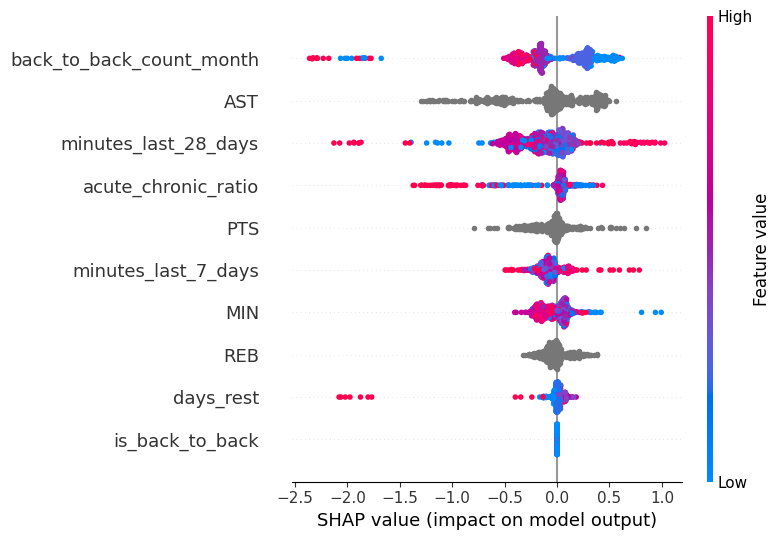

In [19]:
import shap

# Extract just the XGBoost model from the pipeline
xgb_model = pipeline.named_steps['model']

# Transform test data through pipeline steps (without the model)
X_test_transformed = pipeline.named_steps['scaler'].transform(
    pipeline.named_steps['imputer'].transform(X_test)
)

# SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Global summary
shap.summary_plot(shap_values, X_test, feature_names=features)

# SHAP recap:
SHAP tells you which features are pushing injury risk up or down for each game.

What your summary plot showed:

- back_to_back_count_month — biggest driver. Players with more back-to-backs in a month have significantly higher injury risk. Red dots on the right = high back-to-back count = high risk.
- acute_chronic_ratio — second biggest. When recent workload spikes above normal workload, injury risk goes up. This is the sports science insight.
- days_rest — more rest = lower risk (blue dots on left). Makes intuitive sense.
- MIN — high minutes = higher risk overall.

The story your model is telling:

Fatigue accumulation drives injuries more than any single game's workload. It's not one hard game that gets you — it's weeks of back-to-backs with no rest that breaks players down.

That's a genuine sports science finding, and your model learned it purely from data.


#  let's save the model and the data so we can use them in the Streamlit app: 

In [20]:
# Python's serialization library. converts Python objects into bytes that can be written to disk and loaded back later.
import pickle

# Save the pipeline to a file in write-binary (wb) mode
with open('injury_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f) 
    #serializes the entire pipeline object (your trained XGBoost model + any preprocessing steps) 
    #into that file. This freezes the model exactly as it is — weights, parameters, everything 
    # so you don't have to retrain it next time.


# Save the master dataframe to a CSV file for future reference
master_df.to_csv('player_gamelogs.csv', index=False)

print('Model and data saved.')

Model and data saved.
